In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

from pathlib import Path

In [2]:
# Load the cleaned and balanced Yelp dataset.

input_path = "../data/processed/yelp_balanced_150k_cleaned.csv"

df = pd.read_csv(input_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (150000, 6)


In [3]:
# Check the sentiment class distribution.

print("Sentiment distribution:")
print(df["sentiment"].value_counts())

Sentiment distribution:
sentiment
Neutral     50000
Negative    50000
Positive    50000
Name: count, dtype: int64


In [4]:
# X contains the cleaned review text.
# y contains the sentiment labels.

X = df["cleaned_text"]

y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150000,)
y shape: (150000,)


In [5]:
# Split the dataset into training and testing sets.
# Stratification maintains the same class proportions
# in the training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120000
Testing samples: 30000


In [6]:
# Create the TF-IDF vectorizer.
# The configuration is kept identical to Notebook 4
# for a fair comparison between the two models.

tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [7]:
# Fit the TF-IDF vectorizer ONLY on the training data.
# This prevents information from the test data
# from leaking into the training process.

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

Training TF-IDF shape: (120000, 50000)


In [8]:
# Transform the test data using the vocabulary
# learned from the training data.

X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Testing TF-IDF shape: (30000, 50000)


In [9]:
# Create the Multinomial Logistic Regression model.
#
# max_iter is increased because the model is being trained
# on a large TF-IDF feature matrix and may require more
# iterations to converge.

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [10]:
# Train the Logistic Regression model
# using the TF-IDF training data.

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Logistic Regression model trained successfully."
)

Logistic Regression model trained successfully.


In [11]:
# Predict sentiment for the unseen test data.

y_pred_lr = logistic_model.predict(
    X_test_tfidf
)

print("Predictions generated successfully.")
print(
    "Number of predictions:",
    len(y_pred_lr)
)

Predictions generated successfully.
Number of predictions: 30000


In [12]:
# Calculate the overall accuracy.

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

Logistic Regression Accuracy: 0.8605


In [16]:
# Calculate weighted precision, recall, and F1-score.

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Logistic Regression Performance")
print("-"*31)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

Logistic Regression Performance
-------------------------------
Accuracy : 0.8605
Precision: 0.8602100892571779
Recall   : 0.8605
F1-Score : 0.8603379350207826


In [17]:
# Generate a detailed classification report.

lr_classification_report = classification_report(
    y_test,
    y_pred_lr
)

print(
    "Classification Report - Logistic Regression"
)

print()

print(
    lr_classification_report
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

    Negative       0.89      0.90      0.89     10000
     Neutral       0.81      0.80      0.81     10000
    Positive       0.88      0.88      0.88     10000

    accuracy                           0.86     30000
   macro avg       0.86      0.86      0.86     30000
weighted avg       0.86      0.86      0.86     30000



In [18]:
# Generate the confusion matrix.

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[8982  850  168]
 [ 899 8042 1059]
 [ 219  990 8791]]


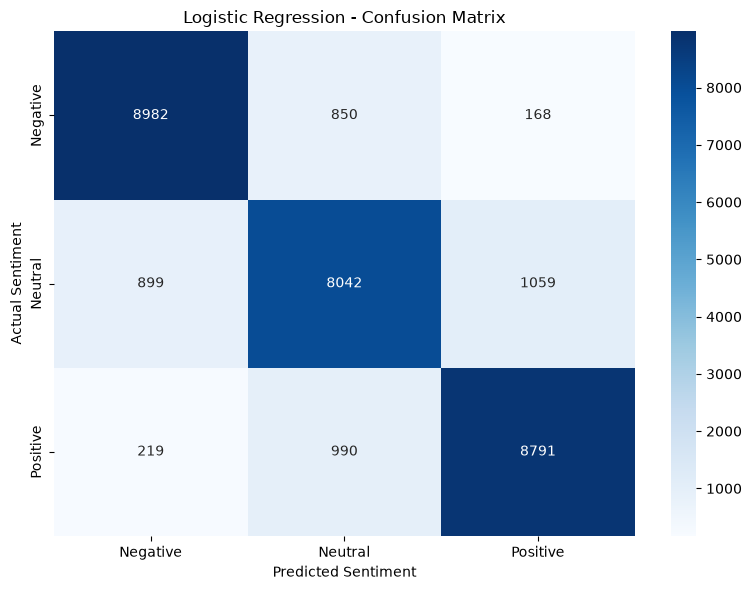

In [19]:
# Plot the Logistic Regression confusion matrix.

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.xlabel(
    "Predicted Sentiment"
)

plt.ylabel(
    "Actual Sentiment"
)

plt.tight_layout()

plt.show()

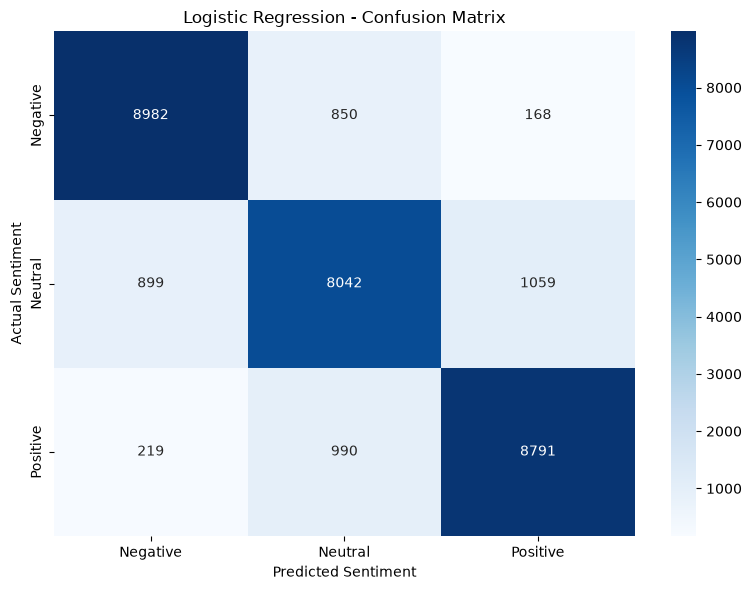

Confusion matrix saved successfully.


In [21]:


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.xlabel(
    "Predicted Sentiment"
)

plt.ylabel(
    "Actual Sentiment"
)

plt.tight_layout()

plt.savefig(
      "../images/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved successfully."
)

In [22]:
# Store Logistic Regression performance metrics
# in a DataFrame.

lr_results = pd.DataFrame({
    "Model": [
        "Multinomial Logistic Regression"
    ],
    "Accuracy": [
        lr_accuracy
    ],
    "Precision": [
        lr_precision
    ],
    "Recall": [
        lr_recall
    ],
    "F1_Score": [
        lr_f1
    ]
})

lr_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Multinomial Logistic Regression,0.8605,0.86021,0.8605,0.860338


In [24]:

# Save Logistic Regression results.

lr_results.to_csv(
    "../results/logistic_regression_results.csv",
    index=False
)

print(
    "Logistic Regression results saved successfully."
)

Logistic Regression results saved successfully.


In [25]:
# Save the fitted TF-IDF vectorizer used by Logistic Regression.

joblib.dump(
    tfidf_vectorizer,
    "../models/tfidf_vectorizer_logistic_regression.pkl"
)

print(
    "TF-IDF vectorizer saved successfully."
)

TF-IDF vectorizer saved successfully.


In [26]:
# Final verification of the Logistic Regression pipeline.

print("LOGISTIC REGRESSION FINAL RESULTS")

print("\nDataset size:")
print(len(df))

print("\nTraining samples:")
print(X_train_tfidf.shape[0])

print("\nTesting samples:")
print(X_test_tfidf.shape[0])

print("\nTF-IDF features:")
print(X_train_tfidf.shape[1])

print("\nModel Performance:")

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

print(
    "\nLogistic Regression training and evaluation completed successfully."
)

LOGISTIC REGRESSION FINAL RESULTS

Dataset size:
150000

Training samples:
120000

Testing samples:
30000

TF-IDF features:
50000

Model Performance:
Accuracy : 0.8605
Precision: 0.8602100892571779
Recall   : 0.8605
F1-Score : 0.8603379350207826

Logistic Regression training and evaluation completed successfully.
